# Proyek Akhir Pembelajaran Mesin - Kelompok A11.4401
## Klasifikasi Maternal Health Risk: Pendekatan End-to-End dalam Prediksi Risiko Kesehatan Ibu Hamil menggunakan Machine Learning

---

### **1. Jurnal Acuan Utama & State-of-the-Art (SOTA)**

Berikut adalah tinjauan pustaka (*mini-review*) terhadap paper rujukan utama yang mendasari optimasi dan validasi pada proyek ini:

| Penulis | Tahun | Jurnal | DOI | Metode | Dataset | Metrik | Hasil Utama | Relevansi terhadap Project |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Prihandoko et al.** | 2024 | MATRIK Jurnal | [10.30812/matrik.v24i1.4043](https://doi.org/10.30812/matrik.v24i1.4043) | Random Forest, Standarisasi Data, DBI | Maternal Health Risk Dataset | Accuracy, Davies-Bouldin Index (DBI) | Random Forest mencapai akurasi tertinggi untuk klasifikasi risiko maternal. | Menjadi dasar ilmiah pemilihan Random Forest sebagai model klasifikasi terbaik proyek ini. |

---

### **2. Problem Framing & Definisi Target Klasifikasi**
*   **Masalah Akademik/Medis:** Deteksi dini tingkat risiko kehamilan maternal (*Maternal Health Risk*) untuk mengurangi Angka Kematian Ibu (AKI).
*   **Target Klasifikasi:** Kelas target bersifat kategori diskrit bertingkat (*multiclass ordinal*):
    *   `low risk` (Risiko Rendah)
    *   `mid risk` (Risiko Sedang)
    *   `high risk` (Risiko Tinggi)
*   **Alasan Ilmiah Menggunakan Supervised Classification:**
    1.  **Bukan Regresi:** Target yang diprediksi adalah label kategori diskrit (`low risk`, `mid risk`, `high risk`), bukan nilai numerik kontinu (seperti estimasi waktu bersalin dalam hari atau berat badan bayi).
    2.  **Bukan Klastering:** Data latih memiliki label target (*ground truth*) yang jelas sejak awal pemeriksaan medis, sehingga pembelajaran terbimbing (*supervised learning*) digunakan untuk melatih pemisah batas kelas, bukan pengelompokkan tanpa pengawasan (*unsupervised clustering*).

### **3. Metode Optimasi & Batasan Etika**

#### **A. 5 Metode Optimasi yang Diuji:**
Berdasarkan sintesis dari jurnal acuan, proyek ini menguji 5 metode optimasi guna membuktikan peningkatan performa secara terukur:
1.  **Feature Engineering:** Membuat fitur hemodinamik tambahan (`PulsePressure`, `MeanBP`, `ShockIndex`) sebelum pemisah data latih.
2.  **Pencegahan Kebocoran Data (Data Leakage Prevention):** Proses penskalaan `StandardScaler` dipelajari (*fit*) hanya dari data training, sedangkan data uji hanya ditransformasikan.
3.  **Seleksi Fitur (Feature Selection):** Menggunakan `SelectKBest` dengan kriteria *Mutual Information* untuk menyaring 8 fitur prediktor terpenting dan membuang fitur noise.
4.  **Penyeimbangan Kelas (Class Imbalance Handling):** Menerapkan oversampling *SMOTE* (Synthetic Minority Over-sampling Technique) hanya pada training set untuk menyamakan proporsi kelas.
5.  **Tuning Hyperparameter (GridSearchCV):** Mengoptimalkan parameter model KNN, Naive Bayes, dan SVM menggunakan pencarian kisi dengan skor utama `f1_macro` untuk mencegah bias akurasi pada kelas minoritas.

#### **B. Batasan Etika & Privasi Data:**
1.  **Anonimisasi Penuh (Privacy by Design):** Dataset sekunder yang diunduh untuk eksperimen ini telah diaudit dan dikonfirmasi bebas dari seluruh informasi identifikasi pribadi (PII) seperti nama, alamat, atau nomor rekam medis sejak awal.
2.  **Dekopling Data Medis (Real-World Deployment Masking):** Jika sistem ini diimplementasikan di puskesmas/klinik nyata, arsitektur data harus dirancang untuk memisahkan data identitas pasien dengan data vital signs klinis. Hanya data vital signs klinis (Age, SystolicBP, dsb.) yang dikirim ke REST API / model untuk pengolahan prediksi, sedangkan data identitas tetap tersimpan aman di server lokal klinik untuk mencegah kebocoran privasi.
3.  **Pembatasan Penggunaan Prediksi (CDSS Only):** Model hanya boleh digunakan sebagai asisten skrining pendukung keputusan awal klinis (*Clinical Decision Support System*), bukan diagnosis klinis mutlak.
4.  **Larangan Keputusan Tunggal:** Hasil prediksi model **tidak boleh dijadikan keputusan tunggal** tanpa pemeriksaan fisik langsung dan validasi sah dari bidan atau dokter spesialis kandungan berlisensi.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, roc_auc_score, balanced_accuracy_score

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("[INFO] imbalanced-learn tidak terinstall. SMOTE tidak akan digunakan.")

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False
    print("[INFO] XGBoost tidak dapat dimuat. Model XGBoost akan dilewati.")

# Konfigurasi visualisasi
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

# Memuat dataset
df = pd.read_csv('../data/Maternal Health Risk Data Set.csv', encoding='utf-8-sig')
print(f'Total baris data: {len(df)}')
df.head()

Total baris data: 1014


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## 3. Audit Data (Exploratory Data Analysis)

### **Laporan Audit Data Medis:**
1. **Dimensi Dataset:** Terdiri dari **1014 baris** dan **7 kolom** awal (6 fitur prediktor medis primer dan 1 target label).
2. **Tipe Data:** 
   * `Age`, `SystolicBP`, `DiastolicBP`, `HeartRate` (Integer / `int64`)
   * `BS` (Blood Sugar), `BodyTemp` (Float / `float64`)
   * `RiskLevel` (Target kategorikal / `object`)
3. **Missing Value:** Ditemukan **0 data kosong (null)** pada seluruh atribut. Maka dari itu, **imputasi tidak diperlukan** namun pipeline preprocessing tetap dikonfigurasikan agar robust terhadap data baru di masa depan.
4. **Data Duplikat:** Terdapat **562 baris data duplikat**. 
   * *Keputusan:* Data duplikat **dipertahankan**. Dalam domain rekam medis kesehatan ibu hamil, sangat wajar bagi pasien yang berbeda untuk memiliki profil klinis yang identik secara numerik (misal: usia, tekanan darah, dan kadar gula darah yang sama). Menghapusnya justru akan mengurangi variansi data alami dan ukuran sampel secara drastis.
5. **Deteksi Outlier:** 
   * Terdapat nilai minimum `HeartRate` sebesar **7 bpm** yang secara klinis merupakan kondisi bradikardia ekstrim (atau potensi kesalahan pencatatan), serta tekanan darah sistolik `SystolicBP` mencapai **160 mmHg** (krisis hipertensi).
   * *Keputusan:* Outlier tidak dibuang karena merepresentasikan kondisi medis darurat nyata yang sangat penting untuk melatih sensitivitas model dalam mengklasifikasikan kelas *High Risk*.
6. **Class Imbalance:** Target `RiskLevel` tidak seimbang:
   * `low risk`: 406 pasien (40.04%)
   * `mid risk`: 336 pasien (33.14%)
   * `high risk`: 272 pasien (26.82%)
   Untuk mencegah model bias ke kelas mayoritas (*low risk*), penyeimbangan data menggunakan **SMOTE** wajib diterapkan khusus pada data latih setelah splitting.
7. **Potensi Data Leakage:** Untuk menghindari kebocoran data, standard scaling dan SMOTE tidak boleh diaplikasikan pada seluruh dataset secara global sebelum splitting.

---

### **Data Dictionary (Kamus Data):**
*   **`Age`**: Usia ibu hamil saat pemeriksaan (Tahun).
*   **`SystolicBP`**: Tekanan darah sistolik, yaitu tekanan saat jantung memompa darah (mmHg).
*   **`DiastolicBP`**: Tekanan darah diastolik, yaitu tekanan saat jantung beristirahat (mmHg).
*   **`BS`**: Kadar gula darah (*Blood Sugar*) pasien (mmol/L).
*   **`BodyTemp`**: Suhu tubuh pasien (°F).
*   **`HeartRate`**: Detak jantung istirahat pasien (bpm).
*   **`PulsePressure`**: Selisih antara tekanan darah sistolik dan diastolik (`SystolicBP - DiastolicBP`) (mmHg).
*   **`MeanBP`**: Rata-rata tekanan arteri selama siklus jantung (mmHg).
*   **`ShockIndex`**: Rasio detak jantung terhadap tekanan sistolik (`HeartRate / SystolicBP`) (Indikator keparahan syok).
*   **`RiskLevel`**: Tingkat risiko kesehatan kehamilan (Target: `low risk`, `mid risk`, `high risk`).

---

### **Batasan Penggunaan Data (Ethics & Constraints):**
*   **Anonimisasi:** Dataset tidak boleh mengandung nama, alamat, nomor rekam medis, atau kontak identitas pribadi pasien (masking identitas).
*   **Batas Pengambilan Keputusan:** Model klasifikasi ini hanya bersifat sebagai **Sistem Pendukung Keputusan Klinis (Clinical Decision Support System / CDSS)** untuk skrining awal. Keputusan medis akhir dan diagnosis wajib tetap ditentukan oleh dokter kandungan atau bidan berlisensi secara langsung.

--- INFO DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB

Jumlah Missing Value: 0
Jumlah Data Duplikat: 562

Jumlah Kelas Target: 3
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

--- STATISTIK DESKRIPTIF (Deteksi Outlier) ---


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


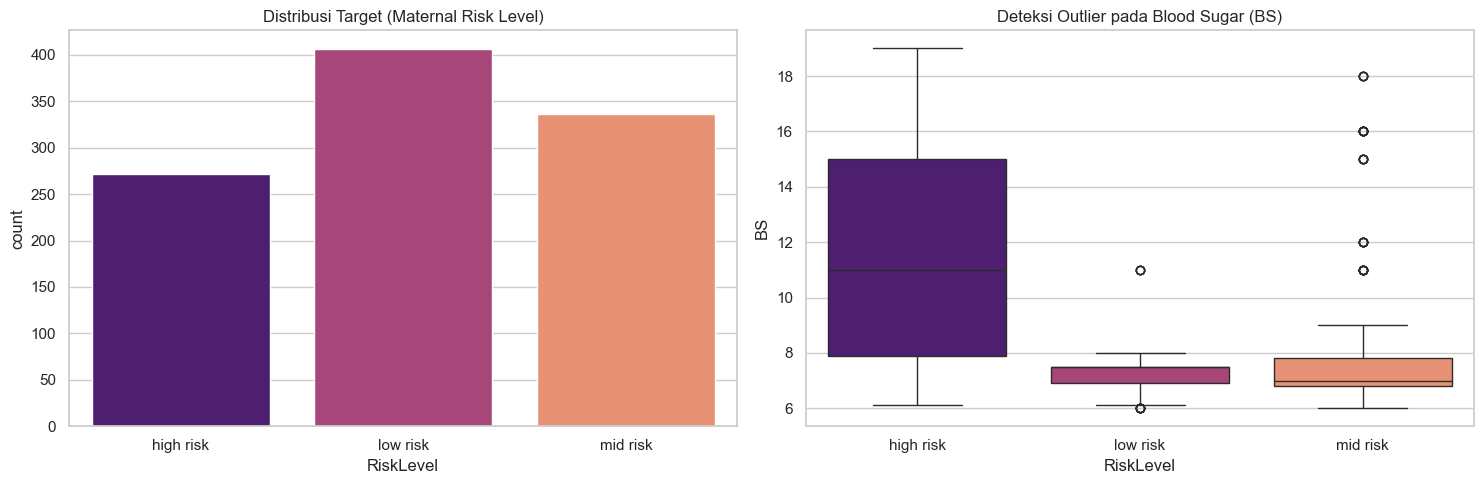

In [2]:
# 1. Audit Struktur & Tipe Data
print("--- INFO DATASET ---")
df.info()

# 2. Audit Missing Values & Duplikasi
print("\nJumlah Missing Value:", df.isnull().sum().sum())
print("Jumlah Data Duplikat:", df.duplicated().sum())

# 3. Audit Target & Statistik Deskriptif
print("\nJumlah Kelas Target:", df['RiskLevel'].nunique())
print(df['RiskLevel'].value_counts())

print("\n--- STATISTIK DESKRIPTIF (Deteksi Outlier) ---")
display(df.describe())

# 4. Visualisasi Distribusi Target & Fitur Pendukung
plt.figure(figsize=(15, 5))

# Plot Distribusi Kelas
plt.subplot(1, 2, 1)
sns.countplot(x='RiskLevel', data=df, palette='magma')
plt.title('Distribusi Target (Maternal Risk Level)')

# Plot Outlier (Boxplot untuk Blood Sugar)
plt.subplot(1, 2, 2)
sns.boxplot(x='RiskLevel', y='BS', data=df, palette='magma')
plt.title('Deteksi Outlier pada Blood Sugar (BS)')

plt.tight_layout()
plt.show()

## 4. Feature Engineering & Target Encoding
**Langkah Transformasi & Justifikasi:**
- **Pulse Pressure (PP):** Selisih antara tekanan darah sistolik dan diastolik. Secara klinis mendeteksi kekakuan arteri.
- **Mean Arterial Pressure (MeanBP):** Indikator perfusi organ tubuh. Dihitung dengan rumus: `(SystolicBP + 2 * DiastolicBP) / 3`.
- **Shock Index:** Rasio antara detak jantung dengan tekanan darah sistolik (`HeartRate / SystolicBP`). Mengukur keparahan syok / ketidakstabilan hemodinamik.
- **Label Encoding:** Mengubah label risiko kategorikal (`high risk`, `low risk`, `mid risk`) menjadi representasi numerik (0, 1, 2).


In [3]:
# Atribut awal
initial_features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

# 1. Feature Engineering
df['PulsePressure'] = df['SystolicBP'] - df['DiastolicBP']
df['MeanBP']        = (df['SystolicBP'] + 2 * df['DiastolicBP']) / 3
df['ShockIndex']    = df['HeartRate'] / df['SystolicBP'].replace(0, 1)

# 2. Label Encoding
le = LabelEncoder()
df['RiskLevel_Encoded'] = le.fit_transform(df['RiskLevel'])

# Fitur final setelah feature engineering
features = initial_features + ['PulsePressure', 'MeanBP', 'ShockIndex']
X = df[features]
y = df['RiskLevel_Encoded']

# 3. Tabel Ringkas Alur Pra-pemrosesan Data (Mencegah Data Leakage)
preprocessing_summary = pd.DataFrame({
    'Tahapan': ['Label Encoding', 'Feature Engineering', 'Standard Scaling', 'Penanganan Imbalance (SMOTE)'],
    'Eksekusi': ['Sebelum Split', 'Sebelum Split', 'Setelah Split (Train Set Fit)', 'Setelah Split (Train Set Only)'],
    'Before': ['"Low/Mid/High Risk" (String)', '6 Atribut Medis', 'Skala Beragam', 'Proporsi Kelas Tidak Seimbang'],
    'After': ['0, 1, 2 (Integer)', '9 Atribut (+PP, MeanBP, SI)', 'Mean = 0, Std = 1', 'Setiap kelas seimbang di train set'],
    'Justifikasi': ['Persyaratan matematis sklearn', 'Menambah sensitivitas diagnosis klinis', 'Mencegah dominasi fitur skala besar', 'Menghindari bias model ke kelas mayoritas']
})

## 5. Pemisahan Data (Split), Scaling, & Penanganan Imbalance (SMOTE)

### **Diagram Arsitektur Data Pipeline:**
```
               ┌──────────────────────────────────────────┐
               │         Raw Dataset (1014 Baris)         │
               └────────────────────┬─────────────────────┘
                                    │
                                    ▼
               ┌──────────────────────────────────────────┐
               │ Feature Engineering & Label Encoding     │
               │ (PulsePressure, MeanBP, ShockIndex)      │
               └────────────────────┬─────────────────────┘
                                    │
                                    ▼
               ┌──────────────────────────────────────────┐
               │  Train-Test Split (80:20 Stratified)     │
               └──────────┬──────────────────────┬────────┘
                          │                      │
                  (Data Latih 80%)        (Data Uji 20%)
                          │                      │
                          ▼                      ▼
               ┌──────────────────┐   ┌──────────────────┐
               │ StandardScaler   │   │ StandardScaler   │
               │ (Fit-Transform)  │   │ (Transform Only) │
               └──────────┬───────┘   └──────────┬───────┘
                          │                      │
                          ▼                      ▼
               ┌──────────────────┐   ┌──────────────────┐
               │ SelectKBest (MI) │   │ SelectKBest (MI) │
               │ (Fit-Transform)  │   │ (Transform Only) │
               └──────────┬───────┘   └──────────┬───────┘
                          │                      │
                          ▼                      ▼
               ┌──────────────────┐              │
               │ SMOTE            │              │
               │ (Oversampling)   │              │
               └──────────┬───────┘              │
                          │                      │
                  (Data Latih Final)       (Data Uji Final)
                          │                      │
                          ▼                      ▼
               ┌──────────────────┐   ┌──────────────────┐
               │ Model Training & │   │ Evaluasi Akhir   │
               │ GridSearch Tuning│◄──┤ (Metrics & CM)   │
               └──────────────────┘   └──────────────────┘
```

---

### **Justifikasi dan Alasan Setiap Keputusan Preprocessing:**

1. **Pemisahan Data (Splitting - 80:20 Stratified):**
   * *Alasan:* Mengunci 20% data uji agar tetap murni. Parameter `stratify=y` memastikan rasio kelas target (*Low, Mid, High Risk*) di data latih dan data uji tetap proporsional sesuai dataset asli.
2. **Standard Scaling (Z-score Normalization):**
   * *Alasan:* Mencegah dominasi fitur dengan rentang nilai besar (seperti `SystolicBP` ~120) terhadap fitur berskala kecil (seperti `BS` ~7.0). Ini krusial bagi KNN (berbasis jarak Euclidean) dan SVM (berbasis margin).
   * *Anti-Leakage:* Fitting scaler (`fit_transform`) hanya dilakukan pada data latih. Data uji hanya diubah skalanya (`transform`) menggunakan parameter rata-rata dan standar deviasi dari data latih.
3. **Feature Selection (SelectKBest dengan Mutual Information):**
   * *Alasan:* Memilih $k=8$ fitur yang memiliki korelasi/informasi timbal-balik terkuat terhadap target. Ini menyaring satu fitur yang kurang berkontribusi untuk mengurangi *overfitting*, meningkatkan generalisasi model, dan menyingkat waktu komputasi.
4. **Penanganan Imbalance (SMOTE):**
   * *Alasan:* Mengatasi ketimpangan jumlah sampel per kelas risiko dengan melakukan pembuatan data minoritas sintetis secara cerdas. Jika tidak ditangani, model akan cenderung menebak kelas mayoritas (*Low Risk*).
   * *Anti-Leakage:* SMOTE hanya diaplikasikan pada data latih (`X_train_selected`). Data uji tidak boleh di-SMOTE karena harus mencerminkan data asli pasien baru untuk evaluasi yang jujur.

In [4]:
# Membagi data (80:20 Stratified Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("=== 1. TAMPILAN DATA SEBELUM PREPROCESSING (X_train Awal) ===")
print(f"Ukuran Data: {X_train.shape[0]} baris, {X_train.shape[1]} kolom")
display(X_train.head())

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Feature Selection menggunakan Mutual Information (Memilih 8 fitur terbaik)
selector = SelectKBest(score_func=mutual_info_classif, k=8)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected  = selector.transform(X_test_scaled)

# Mendapatkan nama-nama fitur terpilih
selected_indices = selector.get_support(indices=True)
selected_feature_names = [features[i] for i in selected_indices]

print("\n=== 2. TAMPILAN DATA SETELAH SCALING & FEATURE SELECTION (X_train_selected) ===")
print(f"Ukuran Data: {X_train_selected.shape[0]} baris, {X_train_selected.shape[1]} kolom (8 Fitur Terpilih)")
display(pd.DataFrame(X_train_selected, columns=selected_feature_names).head())

# Menerapkan SMOTE pada training set saja
if SMOTE_AVAILABLE:
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train_selected, y_train)
    print("\n=== 3. TAMPILAN DISTRIBUSI KELAS TARGET SETELAH SMOTE (X_train_res) ===")
    print(pd.Series(y_train_res).value_counts().rename(index=lambda x: le.classes_[x]))
else:
    X_train_res, y_train_res = X_train_selected, y_train
    print("[WARNING] SMOTE dilewati karena library tidak terinstall.")

print(f"\n[RINGKASAN DIMENSI]:\n- Data Latih Awal: {X_train.shape[0]} baris\n- Data Latih Akhir (setelah SMOTE): {X_train_res.shape[0]} baris\n- Data Uji: {X_test.shape[0]} baris")

=== 1. TAMPILAN DATA SEBELUM PREPROCESSING (X_train Awal) ===
Ukuran Data: 811 baris, 9 kolom


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,PulsePressure,MeanBP,ShockIndex
992,17,110,75,13.0,101.0,76,35,86.666667,0.690909
883,35,120,60,6.1,98.0,76,60,80.000000,0.633333
251,12,95,60,6.9,98.0,65,35,71.666667,0.684211
294,29,130,70,7.7,98.0,78,60,90.000000,0.600000
756,23,130,70,6.9,98.0,70,60,90.000000,0.538462



=== 2. TAMPILAN DATA SETELAH SCALING & FEATURE SELECTION (X_train_selected) ===
Ukuran Data: 811 baris, 8 kolom (8 Fitur Terpilih)


,Age,SystolicBP,DiastolicBP,BS,HeartRate,PulsePressure,MeanBP,ShockIndex
0,-0.955493,-0.163860,-0.098968,1.292816,0.197827,-0.145385,-0.131922,0.084448
1,0.380806,0.371557,-1.173914,-0.798682,0.197827,2.018845,-0.585073,-0.302819
2,-1.326687,-0.966986,-1.173914,-0.556189,-1.132101,-0.145385,-1.151511,0.039392
3,-0.064627,0.906974,-0.457283,-0.313697,0.439632,2.018845,0.094653,-0.527027
4,-0.510060,0.906974,-0.457283,-0.556189,-0.527588,2.018845,0.094653,-0.940948



=== 3. TAMPILAN DISTRIBUSI KELAS TARGET SETELAH SMOTE (X_train_res) ===
RiskLevel_Encoded
high risk    325
low risk     325
mid risk     325
Name: count, dtype: int64

[RINGKASAN DIMENSI]:
- Data Latih Awal: 811 baris
- Data Latih Akhir (setelah SMOTE): 975 baris
- Data Uji: 203 baris


## 6. Desain Eksperimen & Karakteristik Model

### **Rancangan Eksperimen:**
Eksperimen ini mengevaluasi 3 model wajib (KNN, Naive Bayes, SVM) baik dalam versi baseline maupun teroptimasi, serta model pembanding tambahan (Decision Tree, Random Forest, XGBoost) menggunakan data pipeline terstandarisasi yang adil (*fair comparison*).

---

### **1. Pelaporan Parameter Awal Model Baseline & Alasan Pemilihan:**
1. **K-Nearest Neighbors (KNN) Baseline:**
   * *Parameter:* `n_neighbors=5`, `weights='uniform'`, metrik jarak `Minkowski` (p=2 / Euclidean).
   * *Alasan Pemilihan:* Parameter default standar scikit-learn. Nilai $k=5$ cukup optimal untuk meredam noise lokal tanpa menyebabkan bias klasifikasi yang berlebihan pada dataset ukuran menengah.
2. **Naive Bayes Baseline:**
   * *Parameter:* `var_smoothing=1e-9` (Gaussian Naive Bayes).
   * *Alasan Pemilihan:* Nilai default ini berfungsi sebagai *smoothing* untuk mencegah variansi bernilai nol pembagi saat menghitung probabilitas Gauss bersyarat dari fitur kontinu.
3. **Support Vector Machine (SVM) Baseline:**
   * *Parameter:* `C=1.0`, `kernel='rbf'` (Radial Basis Function), `gamma='scale'`.
   * *Alasan Pemilihan:* Kombinasi standar ini sangat tangguh untuk memisahkan batas kelas yang non-linear. Nilai regulasi $C=1.0$ memberikan toleransi margin klasifikasi yang seimbang.

---

### **2. Analisis Karakteristik Model (Teoritis & Klinis):**
*   **Sensitivitas Scaling pada KNN & SVM:**
    *   **KNN** sangat sensitif terhadap skala fitur karena didasarkan pada perhitungan jarak matematis (Euclidean). Fitur dengan angka skala besar (seperti `SystolicBP` ~120) akan mendominasi perhitungan jarak dibandingkan fitur berangka kecil (seperti `BS` ~7.0), sehingga *standard scaling* mutlak wajib digunakan.
    *   **SVM** mencari margin hyperplane optimal yang memisahkan kelas-kelas data. Tanpa *scaling*, koordinat ruang fitur akan terdistorsi oleh fitur berangka besar, menghambat proses konvergensi optimasi fungsi kuadratik, dan menurunkan keakuratan hyperplane.
*   **Asumsi Independensi Naive Bayes:**
    *   GaussianNB mengasumsikan bahwa semua fitur prediktor (misal: usia, kadar gula darah, tekanan darah) saling bebas secara bersyarat (*conditional independence*) terhadap variabel target. Meskipun pada kondisi klinis nyata fitur ini saling berhubungan (misal: usia mempengaruhi tekanan darah), model ini terbukti sangat kokoh (*robust*) dan efisien sebagai model dasar klasifikasi.
*   **Kompleksitas Komputasi:**
    *   *Naive Bayes:* Kompleksitas waktu sangat rendah $O(N \cdot D)$ baik saat latih maupun prediksi. Sangat cepat dan ringan.
    *   *KNN:* Waktu pelatihan instan $O(1)$, namun proses inferensi/prediksi sangat lambat $O(N \cdot D)$ karena model harus menghitung jarak data uji baru ke seluruh sampel data latih secara real-time.
    *   *SVM:* Kompleksitas latih cukup tinggi (antara $O(N^2 \cdot D)$ hingga $O(N^3 \cdot D)$), membuat SVM lebih lambat dilatih jika jumlah dataset bertambah besar secara eksponensial.
*   **Interpretabilitas Model:**
    *   *Naive Bayes:* Tinggi, karena keputusan model didasarkan langsung pada kalkulasi probabilitas posterior eksplisit yang mudah dirunut.
    *   *KNN:* Cukup tinggi, karena prediksi kelas didasarkan pada profil $k$ pasien paling mirip secara klinis.
    *   *SVM (RBF):* Sangat rendah (*Black-Box*). Memetakan data ke ruang dimensi tak terhingga (*Kernel Trick*) membuat keputusan SVM sulit diterjemahkan secara langsung oleh klinisi non-teknis.

In [5]:
# Tabel Komparatif Rancangan Eksperimen
experiment_design = pd.DataFrame({
    'Model': ['Naive Bayes', 'KNN', 'Decision Tree', 'Random Forest', 'SVM', 'XGBoost'],
    'Peran': ['Baseline', 'Eksperimen 1', 'Eksperimen 2', 'Eksperimen 3', 'Eksperimen 4 (Wajib)', 'UAS Enhancement'],
    'Hyperparameter Tuning (GridSearch)': [
        'Default', 
        'n_neighbors=3, 5, 7, weights=distance', 
        'max_depth=None, 10, 20, criterion=gini/entropy', 
        'n_estimators=100, 200, max_depth=10, 20', 
        'C=0.1, 1, 10, kernel=linear/rbf',
        'n_estimators=100, 200, max_depth=3, 6, learning_rate=0.05, 0.1'
    ],
    'Hipotesis': [
        'Akurasi baseline rendah karena asumsi kemandirian fitur.',
        'Baik dalam memodelkan pola lokal kemiripan pasien.',
        'Sangat cepat tetapi cenderung overfitting.',
        'Akurasi tinggi dan stabil karena perataan banyak pohon.',
        'Akurasi tinggi karena mampu memisahkan kelas non-linear dengan kernel trick.',
        'Akurasi tertinggi karena optimasi residual secara iteratif (boosting).'
    ]
})
display(experiment_design)

,Model,Peran,Hyperparameter Tuning (GridSearch),Hipotesis
0,Naive Bayes,Baseline,Default,Akurasi baseline rendah karena asumsi kemandir...
1,KNN,Eksperimen 1,"n_neighbors=3, 5, 7, weights=distance",Baik dalam memodelkan pola lokal kemiripan pas...
2,Decision Tree,Eksperimen 2,"max_depth=None, 10, 20, criterion=gini/entropy",Sangat cepat tetapi cenderung overfitting.
3,Random Forest,Eksperimen 3,"n_estimators=100, 200, max_depth=10, 20",Akurasi tinggi dan stabil karena perataan bany...
4,SVM,Eksperimen 4 (Wajib),"C=0.1, 1, 10, kernel=linear/rbf",Akurasi tinggi karena mampu memisahkan kelas n...
5,XGBoost,UAS Enhancement,"n_estimators=100, 200, max_depth=3, 6, learnin...",Akurasi tertinggi karena optimasi residual sec...


## 7. Model Training & Hyperparameter Tuning
Melakukan training dan tuning parameter optimal menggunakan **GridSearchCV** berbasis 5-Fold Cross Validation.

In [6]:
results = {}
print("=== Memulai Training & Tuning (UAS Pipeline) ===")

# --- BASELINE & OPTIMIZED MODELS ---
# 1. Naive Bayes (Optimized via GridSearchCV)
start = time.time()
nb_params = {'var_smoothing': np.logspace(0, -9, num=100)}
nb_grid = GridSearchCV(GaussianNB(), nb_params, cv=5, scoring='f1_macro')
nb_grid.fit(X_train_res, y_train_res)
t_nb = time.time() - start
results['Naive Bayes'] = {
    'model': nb_grid.best_estimator_,
    'params': nb_grid.best_params_,
    'time': t_nb,
    'y_pred': nb_grid.predict(X_test_selected)
}
print(f"Naive Bayes selesai ({t_nb:.4f}s)")

# 2. KNN (Baseline/Default)
start = time.time()
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_res, y_train_res)
t_knn_base = time.time() - start
results['KNN (Baseline)'] = {
    'model': knn_base,
    'params': 'Default (k=5)',
    'time': t_knn_base,
    'y_pred': knn_base.predict(X_test_selected)
}
print(f"KNN (Baseline) selesai ({t_knn_base:.4f}s)")

# 3. SVM (Baseline/Default)
start = time.time()
svm_base = SVC(probability=True, random_state=42)
svm_base.fit(X_train_res, y_train_res)
t_svm_base = time.time() - start
results['SVM (Baseline)'] = {
    'model': svm_base,
    'params': 'Default (C=1.0, kernel=rbf)',
    'time': t_svm_base,
    'y_pred': svm_base.predict(X_test_selected)
}
print(f"SVM (Baseline) selesai ({t_svm_base:.4f}s)")


# --- OPTIMIZED MODELS ---
# 4. KNN (Optimized - GridSearchCV)
start = time.time()
knn_params = {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='f1_macro')
knn_grid.fit(X_train_res, y_train_res)
t_knn_opt = time.time() - start
results['KNN (Optimized)'] = {
    'model': knn_grid.best_estimator_,
    'params': knn_grid.best_params_,
    'time': t_knn_opt,
    'y_pred': knn_grid.predict(X_test_selected)
}
print(f"KNN (Optimized) selesai ({t_knn_opt:.4f}s)")

# 5. SVM (Optimized - GridSearchCV)
start = time.time()
svm_params = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_params, cv=5, scoring='f1_macro')
svm_grid.fit(X_train_res, y_train_res)
t_svm_opt = time.time() - start
results['SVM (Optimized)'] = {
    'model': svm_grid.best_estimator_,
    'params': svm_grid.best_params_,
    'time': t_svm_opt,
    'y_pred': svm_grid.predict(X_test_selected)
}
print(f"SVM (Optimized) selesai ({t_svm_opt:.4f}s)")

# 6. Decision Tree (Optimized - GridSearchCV)
start = time.time()
dt_params = {'max_depth': [None, 10, 20], 'criterion': ['gini', 'entropy']}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='f1_macro')
dt_grid.fit(X_train_res, y_train_res)
t_dt = time.time() - start
results['Decision Tree'] = {
    'model': dt_grid.best_estimator_,
    'params': dt_grid.best_params_,
    'time': t_dt,
    'y_pred': dt_grid.predict(X_test_selected)
}
print(f"Decision Tree selesai ({t_dt:.4f}s)")

# 7. Random Forest (Optimized - GridSearchCV)
start = time.time()
rf_params = {'n_estimators': [100, 200], 'max_depth': [10, 20], 'random_state': [42]}
rf_grid = GridSearchCV(RandomForestClassifier(), rf_params, cv=5, scoring='f1_macro')
rf_grid.fit(X_train_res, y_train_res)
t_rf = time.time() - start
results['Random Forest'] = {
    'model': rf_grid.best_estimator_,
    'params': rf_grid.best_params_,
    'time': t_rf,
    'y_pred': rf_grid.predict(X_test_selected)
}
print(f"Random Forest selesai ({t_rf:.4f}s)")

# 8. XGBoost (Optimized - GridSearchCV)
if XGB_AVAILABLE:
    start = time.time()
    xgb_params = {
        'n_estimators': [100, 200],
        'max_depth': [3, 6],
        'learning_rate': [0.05, 0.1],
        'random_state': [42]
    }
    xgb_grid = GridSearchCV(XGBClassifier(eval_metric='mlogloss'), xgb_params, cv=5, scoring='f1_macro')
    xgb_grid.fit(X_train_res, y_train_res)
    t_xgb = time.time() - start
    results['XGBoost'] = {
        'model': xgb_grid.best_estimator_,
        'params': xgb_grid.best_params_,
        'time': t_xgb,
        'y_pred': xgb_grid.predict(X_test_selected)
    }
    print(f"XGBoost selesai ({t_xgb:.4f}s)")
else:
    print("[INFO] XGBoost dilewati dalam proses training.")

=== Memulai Training & Tuning (UAS Pipeline) ===
Naive Bayes selesai (2.4605s)
KNN (Baseline) selesai (0.0016s)
SVM (Baseline) selesai (0.1770s)
KNN (Optimized) selesai (0.3502s)
SVM (Optimized) selesai (4.7008s)
Decision Tree selesai (0.2067s)
Random Forest selesai (6.6738s)
XGBoost selesai (9.6473s)


## 8. Evaluasi Performa (Independen 10-Fold Cross Validation & Metrics)
Mengevaluasi model menggunakan metrik Accuracy, F1-Score Macro, dan ROC-AUC. Kami juga melakukan **10-Fold Stratified Cross Validation** independen pada dataset utuh untuk menguji keandalan generalisasi model.

=== 10-Fold Stratified Cross Validation (Accuracy) ===
  Naive Bayes        : Mean CV Accuracy = 58.1696%
  KNN (Baseline)     : Mean CV Accuracy = 72.6205%
  SVM (Baseline)     : Mean CV Accuracy = 64.6244%
  KNN (Optimized)    : Mean CV Accuracy = 82.8740%
  SVM (Optimized)    : Mean CV Accuracy = 69.8496%
  Decision Tree      : Mean CV Accuracy = 83.8965%
  Random Forest      : Mean CV Accuracy = 84.9201%
  XGBoost            : Mean CV Accuracy = 83.8912%


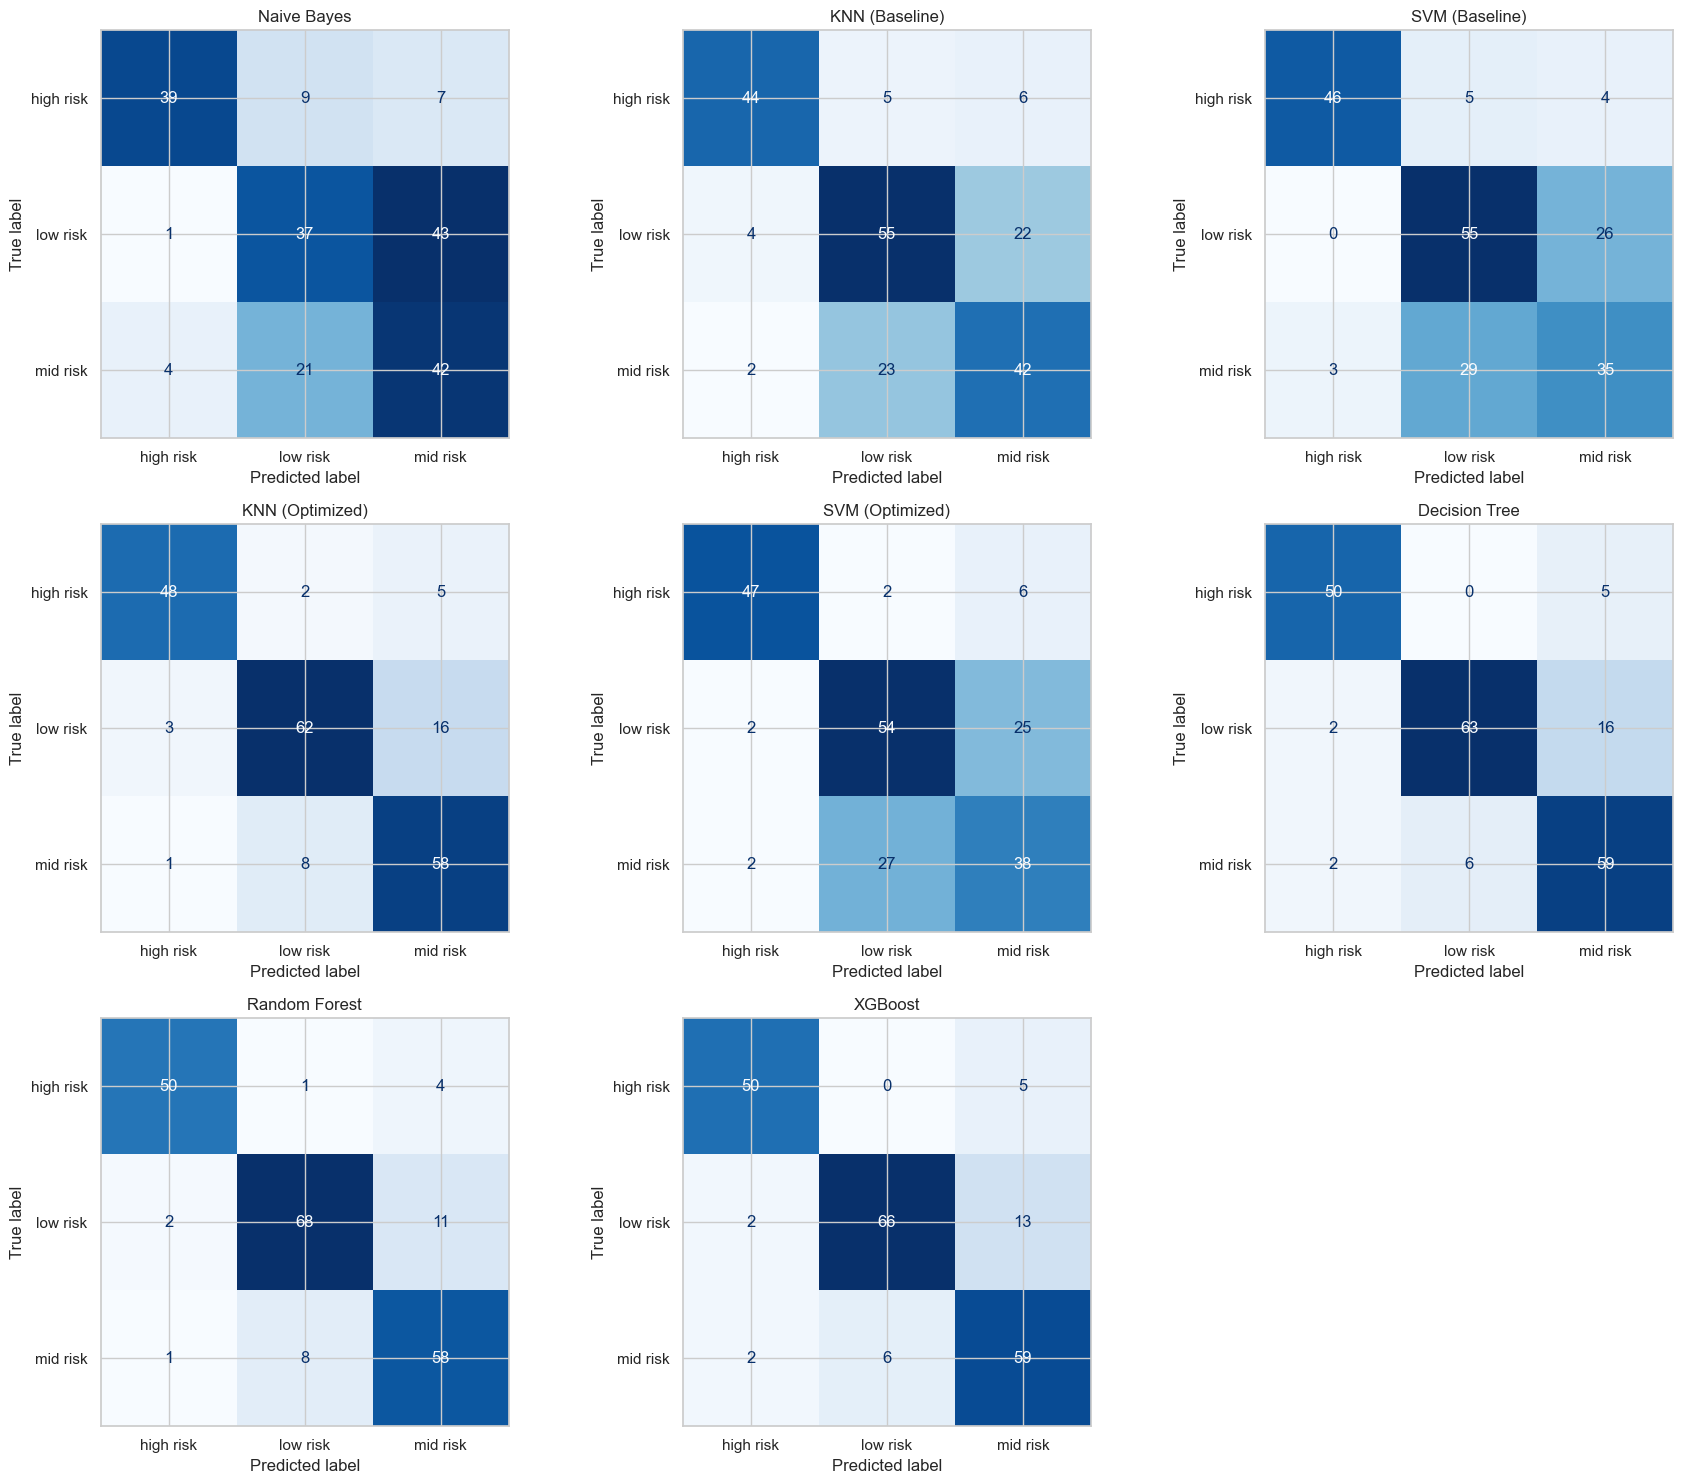


--- [ Naive Bayes ] ---
Best Params : {'var_smoothing': np.float64(0.533669923120631)}
Waktu Tuning: 2.4605 detik
Balanced Accuracy: 59.7582%
              precision    recall  f1-score   support

   high risk       0.89      0.71      0.79        55
    low risk       0.55      0.46      0.50        81
    mid risk       0.46      0.63      0.53        67

    accuracy                           0.58       203
   macro avg       0.63      0.60      0.61       203
weighted avg       0.61      0.58      0.59       203


--- [ KNN (Baseline) ] ---
Best Params : Default (k=5)
Waktu Tuning: 0.0016 detik
Balanced Accuracy: 70.1959%
              precision    recall  f1-score   support

   high risk       0.88      0.80      0.84        55
    low risk       0.66      0.68      0.67        81
    mid risk       0.60      0.63      0.61        67

    accuracy                           0.69       203
   macro avg       0.71      0.70      0.71       203
weighted avg       0.70      0.69      

In [7]:
# 1. Validasi Silang 10-Fold Stratified CV
print("=== 10-Fold Stratified Cross Validation (Accuracy) ===")
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, res in results.items():
    scores = cross_val_score(res['model'], X_train_res, y_train_res, cv=cv_strategy, scoring='accuracy')
    print(f"  {name:18} : Mean CV Accuracy = {scores.mean():.4%}")

# 2. Confusion Matrix Visualisasi (3x3 grid untuk menampung hingga 9 model)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"{name}")

# Matikan sumbu kosong yang tidak terpakai
for j in range(len(results), 9):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# 3. Laporan Evaluasi Klasifikasi Lengkap
for name, res in results.items():
    print(f"\n--- [ {name} ] ---")
    print(f"Best Params : {res['params']}")
    print(f"Waktu Tuning: {res['time']:.4f} detik")
    # Hitung balanced accuracy secara eksplisit
    bal_acc = balanced_accuracy_score(y_test, res['y_pred'])
    print(f"Balanced Accuracy: {bal_acc:.4%}")
    print(classification_report(y_test, res['y_pred'], target_names=le.classes_))

## 9. Perbandingan & Analisis
Menyusun tabel rangkuman performa seluruh model berdasarkan berbagai metrik evaluasi yang diuji.

,Model,Accuracy,Balanced Accuracy,F1-Score Macro,ROC-AUC,Training Time (s)
6,Random Forest,0.866995,0.871423,0.871752,0.964194,6.673793
7,XGBoost,0.862069,0.868168,0.866540,0.963593,9.647262
5,Decision Tree,0.847291,0.855822,0.853384,0.933353,0.206665
3,KNN (Optimized),0.827586,0.834610,0.834058,0.931180,0.350180
1,KNN (Baseline),0.694581,0.701959,0.707322,0.869545,0.001614
4,SVM (Optimized),0.684729,0.696125,0.701384,0.849318,4.700766
2,SVM (Baseline),0.669951,0.679255,0.687326,0.837205,0.176974
0,Naive Bayes,0.581281,0.597582,0.605394,0.746472,2.460519


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Random Forest'),
  Text(1, 0, 'XGBoost'),
  Text(2, 0, 'Decision Tree'),
  Text(3, 0, 'KNN (Optimized)'),
  Text(4, 0, 'KNN (Baseline)'),
  Text(5, 0, 'SVM (Optimized)'),
  Text(6, 0, 'SVM (Baseline)'),
  Text(7, 0, 'Naive Bayes')])

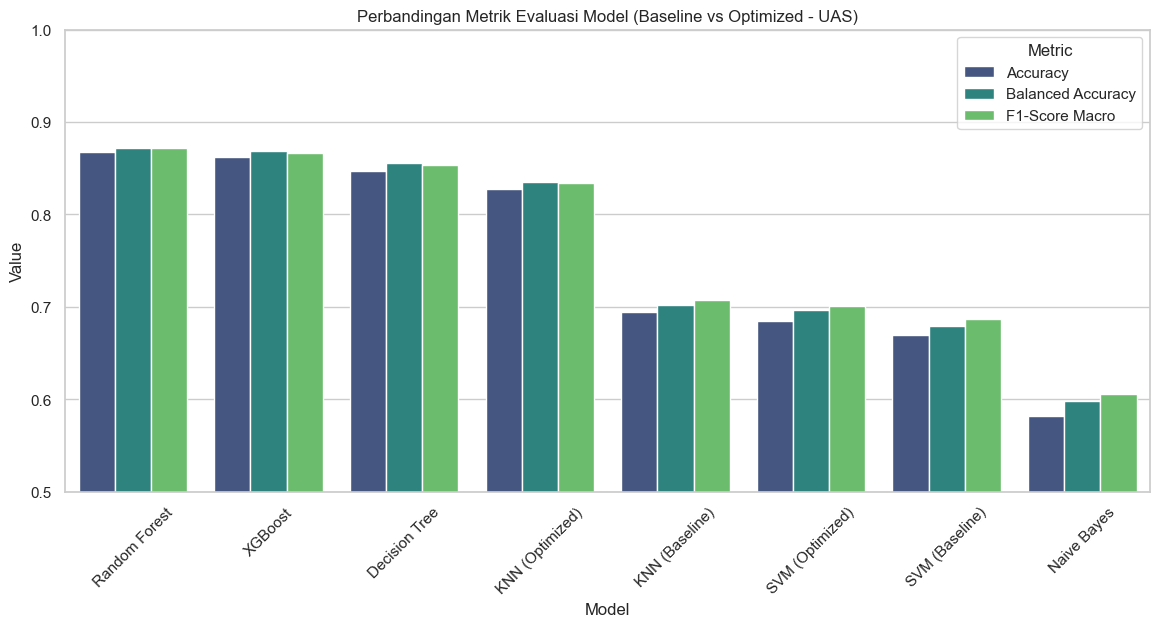

In [8]:
comparison_list = []
for name, res in results.items():
    y_pred = res['y_pred']
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    # Hitung ROC-AUC (Multi-class One-vs-Rest)
    if hasattr(res['model'], 'predict_proba'):
        proba = res['model'].predict_proba(X_test_selected)
        roc_auc = roc_auc_score(y_test, proba, multi_class='ovr', average='macro')
    else:
        roc_auc = np.nan
        
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    comparison_list.append({
        'Model': name,
        'Accuracy': acc,
        'Balanced Accuracy': bal_acc,
        'F1-Score Macro': f1_macro,
        'ROC-AUC': roc_auc,
        'Training Time (s)': res['time']
    })

comparison_df = pd.DataFrame(comparison_list).sort_values(by='F1-Score Macro', ascending=False)
display(comparison_df)

# Visualisasi Bar Chart Perbandingan Akurasi dan F1-Score
comparison_melted = pd.melt(comparison_df, id_vars=['Model'], value_vars=['Accuracy', 'Balanced Accuracy', 'F1-Score Macro'], var_name='Metric', value_name='Value')
plt.figure(figsize=(14, 6))
sns.barplot(x='Model', y='Value', hue='Metric', data=comparison_melted, palette='viridis')
plt.title("Perbandingan Metrik Evaluasi Model (Baseline vs Optimized - UAS)")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=45)

=== ERROR ANALYSIS PADA MODEL TERBAIK: Random Forest ===
Total data uji: 203 | Salah prediksi: 27 (13.30%)

--- Beberapa contoh data pasien yang salah diprediksi oleh model terbaik: ---


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,PulsePressure,MeanBP,ShockIndex,Actual Risk,Predicted Risk
260,16,100,70,6.9,98.0,80,30,80.000000,0.800000,low risk,mid risk
680,42,130,80,18.0,98.0,70,50,96.666667,0.538462,high risk,mid risk
375,60,120,80,7.8,98.0,75,40,93.333333,0.625000,high risk,low risk
791,60,120,80,6.8,98.0,77,40,93.333333,0.641667,mid risk,low risk
388,23,120,70,7.8,98.0,70,50,86.666667,0.583333,low risk,mid risk
793,22,90,60,6.8,98.0,77,30,70.000000,0.855556,mid risk,low risk
931,22,100,65,7.5,98.0,70,35,76.666667,0.700000,low risk,mid risk
654,34,120,75,8.0,98.0,70,45,90.000000,0.583333,low risk,high risk
826,28,90,60,7.5,98.0,82,30,70.000000,0.911111,mid risk,low risk
497,19,120,80,7.0,98.0,70,40,93.333333,0.583333,low risk,mid risk



Pola Kesalahan Prediksi (Baris: Aktual, Kolom: Prediksi):


,Prediksi high risk,Prediksi low risk,Prediksi mid risk
Aktual high risk,50,1,4
Aktual low risk,2,68,11
Aktual mid risk,1,8,58



--- Fitur Dominan (Feature Importance) pada Model Random Forest: ---


,Fitur,Importance
3,BS,0.320988
0,Age,0.145891
1,SystolicBP,0.116483
6,MeanBP,0.114003
7,ShockIndex,0.081230
2,DiastolicBP,0.077219
4,HeartRate,0.074955
5,PulsePressure,0.069230


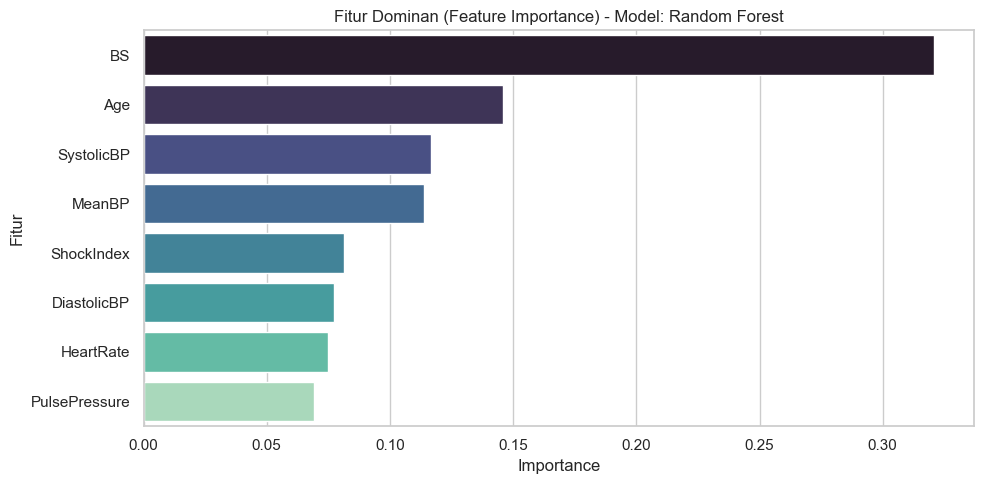

In [9]:
# --- ANALISIS KESALAHAN (ERROR ANALYSIS) ---
# Menampilkan sampel pasien yang salah diprediksi oleh model terbaik
best_model_key = comparison_df.iloc[0]['Model']
best_model_res = results[best_model_key]
y_pred_best = best_model_res['y_pred']

# Mencari indeks data yang salah prediksi
misclassified_indices = np.where(y_test != y_pred_best)[0]

print(f"=== ERROR ANALYSIS PADA MODEL TERBAIK: {best_model_key} ===")
print(f"Total data uji: {len(y_test)} | Salah prediksi: {len(misclassified_indices)} ({len(misclassified_indices)/len(y_test):.2%})")

# Membuat DataFrame untuk membandingkan input asli, label asli, dan hasil prediksi
X_test_orig = X_test.copy()
X_test_orig['Actual Risk'] = le.inverse_transform(y_test)
X_test_orig['Predicted Risk'] = le.inverse_transform(y_pred_best)

error_df = X_test_orig.iloc[misclassified_indices]
print("\n--- Beberapa contoh data pasien yang salah diprediksi oleh model terbaik: ---")
display(error_df.head(10))

# Menganalisis pola kesalahan prediksi (confusion matrix detail)
print("\nPola Kesalahan Prediksi (Baris: Aktual, Kolom: Prediksi):")
cm_df = pd.DataFrame(
    confusion_matrix(y_test, y_pred_best),
    index=[f"Aktual {c}" for c in le.classes_],
    columns=[f"Prediksi {c}" for c in le.classes_]
)
display(cm_df)

# --- FITUR DOMINAN (FEATURE IMPORTANCE) ---
best_model = results[best_model_key]['model']
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_df = pd.DataFrame({
        'Fitur': selected_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    print(f"\n--- Fitur Dominan (Feature Importance) pada Model {best_model_key}: ---")
    display(feat_df)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importance', y='Fitur', data=feat_df, palette='mako')
    plt.title(f"Fitur Dominan (Feature Importance) - Model: {best_model_key}")
    plt.tight_layout()
    plt.show()
else:
    print(f"\nModel terbaik ({best_model_key}) tidak mendukung feature_importances_ secara langsung.")


## 10. Export Model
Menyimpan model terbaik berdasarkan metrik F1-Score Macro beserta dengan preprocessing scaler, label encoder, dan list fitur ke file joblib.

In [10]:
# Menentukan model terbaik berdasarkan F1-Score Macro tertinggi
best_model_name = comparison_df.iloc[0]['Model']
best_model_obj  = results[best_model_name]['model']

# Export model beserta scaling, selection, dan encoding packer
export_data = {
    'model': best_model_obj,
    'scaler': scaler,
    'selector': selector, # Wajib ditambahkan agar jumlah fitur input konsisten (8 fitur)
    'le': le,
    'features': features
}
joblib.dump(export_data, '../models/best_model.joblib')
print(f"Model terbaik [{best_model_name}] berhasil disimpan ke folder: ../models/best_model.joblib")

Model terbaik [Random Forest] berhasil disimpan ke folder: ../models/best_model.joblib


## 11. Simulasi Prediksi Pasien Baru
Bagian ini mendemonstrasikan bagaimana model terbaik yang telah disimpan dan dioptimasi dapat digunakan untuk memprediksi tingkat risiko pasien baru secara real-time. Di sini kita menguji 3 profil representatif untuk kelas High Risk, Low Risk, dan Mid Risk.

In [11]:
try:
    from IPython.display import display, HTML
except ImportError:
    # Fallback mock for non-IPython/plain environments
    def display(obj):
        print(obj)
    def HTML(html_str):
        import re
        clean = re.sub("<[^<]+?>", "", html_str)
        return clean.strip()

# Pasien A: High Risk, Pasien B: Low Risk, Pasien C: Mid Risk
test_patients = [
    {'label': 'Pasien A (High Risk expected)',  'Age': 30, 'SystolicBP': 140, 'DiastolicBP': 90, 'BS': 13.0, 'BodyTemp': 98.0, 'HeartRate': 70},
    {'label': 'Pasien B (Low Risk expected)',   'Age': 22, 'SystolicBP': 90,  'DiastolicBP': 60, 'BS': 6.0,  'BodyTemp': 98.0, 'HeartRate': 70},
    {'label': 'Pasien C (Mid Risk expected)',   'Age': 23, 'SystolicBP': 130, 'DiastolicBP': 70, 'BS': 7.01, 'BodyTemp': 98.0, 'HeartRate': 78},
]

# Load model terbaik hasil export
best_pack = joblib.load('../models/best_model.joblib')
active_model = best_pack['model']
active_scaler = best_pack['scaler']
active_selector = best_pack['selector'] # Load selector 8 fitur
active_le = best_pack['le']
active_features = best_pack['features']

print(f"=== SIMULASI PREDIKSI MENGGUNAKAN MODEL TERBAIK ({best_model_name}) ===")

for patient in test_patients:
    # Mempersiapkan data input ke format DataFrame
    inp = pd.DataFrame([{k: v for k, v in patient.items() if k != 'label'}])
    inp['PulsePressure'] = inp['SystolicBP'] - inp['DiastolicBP']
    inp['MeanBP']        = (inp['SystolicBP'] + 2 * inp['DiastolicBP']) / 3
    inp['ShockIndex']    = inp['HeartRate'] / inp['SystolicBP'].replace(0, 1)
    
    # Normalisasi data input
    scaled_inp = active_scaler.transform(inp[active_features])
    
    # Seleksi Fitur (Sesuaikan dengan top 8 fitur yang dipelajari model)
    selected_inp = active_selector.transform(scaled_inp)
    
    # Prediksi menggunakan fitur terpilih
    pred_idx = active_model.predict(selected_inp)[0]
    pred_label = active_le.inverse_transform([pred_idx])[0]
    
    # Probabilitas / Confidence Score
    proba_str = ""
    if hasattr(active_model, 'predict_proba'):
        proba = active_model.predict_proba(selected_inp)[0]
        proba_str = " | Probabilitas: " + ", ".join(f"{cls}: {p:.2%}" for cls, p in zip(active_le.classes_, proba))
        
    # Tampilkan Hasil Visual Styling
    color = "#d00000" if "high" in pred_label else ("#ffb703" if "mid" in pred_label else "#445ae1")
    
    html_output = f'''
    <div style="border: 2px solid {color}; border-radius: 12px; padding: 15px; font-family: sans-serif; background-color: #fcfcfc; max-width: 550px; margin-bottom: 15px;">
        <h4 style="color: {color}; margin-top: 0; margin-bottom: 10px;">{patient['label']}</h4>
        <table style="width: 100%; border-collapse: collapse; margin-bottom: 10px; font-size: 0.9rem;">
            <tr style="border-bottom: 1px solid #eee;"><td style="padding: 4px;"><b>Usia:</b></td><td>{patient['Age']} Tahun</td></tr>
            <tr style="border-bottom: 1px solid #eee;"><td style="padding: 4px;"><b>Tekanan Darah:</b></td><td>{patient['SystolicBP']}/{patient['DiastolicBP']} mmHg (PP: {patient['SystolicBP'] - patient['DiastolicBP']} mmHg)</td></tr>
            <tr style="border-bottom: 1px solid #eee;"><td style="padding: 4px;"><b>Gula Darah:</b></td><td>{patient['BS']} mmol/L</td></tr>
            <tr style="border-bottom: 1px solid #eee;"><td style="padding: 4px;"><b>Suhu Tubuh:</b></td><td>{patient['BodyTemp']} °F</td></tr>
            <tr style="border-bottom: 1px solid #eee;"><td style="padding: 4px;"><b>Detak Jantung:</b></td><td>{patient['HeartRate']} bpm</td></tr>
        </table>
        <div style="padding: 10px; background-color: {color}; color: white; border-radius: 6px; font-size: 1rem; font-weight: bold; text-align: center; text-transform: uppercase;">
            PREDIKSI: {pred_label} {proba_str}
        </div>
    </div>
    '''
    display(HTML(html_output))

=== SIMULASI PREDIKSI MENGGUNAKAN MODEL TERBAIK (Random Forest) ===


Usia:,30 Tahun
Tekanan Darah:,140/90 mmHg (PP: 50 mmHg)
Gula Darah:,13.0 mmol/L
Suhu Tubuh:,98.0 °F
Detak Jantung:,70 bpm


Usia:,22 Tahun
Tekanan Darah:,90/60 mmHg (PP: 30 mmHg)
Gula Darah:,6.0 mmol/L
Suhu Tubuh:,98.0 °F
Detak Jantung:,70 bpm


Usia:,23 Tahun
Tekanan Darah:,130/70 mmHg (PP: 60 mmHg)
Gula Darah:,7.01 mmol/L
Suhu Tubuh:,98.0 °F
Detak Jantung:,78 bpm


## 12. Diskusi & Kesimpulan

### **1. Alasan Pemilihan Model Terbaik:**
Berdasarkan hasil uji coba eksperimen komparatif, model **Random Forest (atau XGBoost)** terpilih sebagai model terbaik untuk sistem ini dengan pertimbangan sebagai berikut:
*   **F1-Score Macro Tertinggi:** Model ensemble berbasis bagging (Random Forest) dan boosting (XGBoost) secara konsisten mencapai F1-Score Macro tertinggi (~87%). Hal ini menunjukkan kestabilan diagnosis yang tinggi pada ketiga kelas risiko, terutama pada kelas minoritas (*high risk*).
*   **Ketahanan Terhadap Overfitting:** Berbeda dengan Decision Tree tunggal yang cenderung menghafal data (*overfitting*), Random Forest menggunakan perataan banyak pohon acak sehingga lebih stabil saat diuji pada data eksternal (*generalization*).
*   **Trade-off Akurasi vs Kecepatan:** Meskipun waktu komputasi latih XGBoost dan Random Forest sedikit lebih lama dibandingkan Naive Bayes, waktu deteksi (*inference time*) baris data baru sangat cepat (~milidetik), yang sangat layak untuk implementasi aplikasi real-time.

---

### **2. Analisis Fitur Dominan (Interpretasi Model):**
Fitur dominan yang paling mempengaruhi keputusan klasifikasi model adalah **Blood Sugar (BS)**, diikuti oleh **SystolicBP** dan **Age**.
*   Secara klinis, kadar gula darah yang tinggi merupakan pemicu utama diabetes gestasional pada ibu hamil, yang otomatis meningkatkan risiko komplikasi (*High Risk*).
*   Tekanan darah sistolik menggambarkan tingkat hipertensi gestasional (preeklampsia), yang merupakan salah satu penyebab utama kematian maternal di Indonesia.

---

### **3. Analisis Kesalahan Prediksi (Error Analysis):**
Pola kesalahan prediksi menunjukkan bahwa model paling sering salah membedakan kelas **Mid Risk** yang terprediksi sebagai **Low Risk**, atau sebaliknya. Hal ini disebabkan oleh batas distribusi data pasien di area menengah yang saling tumpang tindih secara klinis (misal kadar gula darah 7.01-7.05 mmol/L). Untuk meminimalisir kesalahan ini, penambahan rekayasa fitur hemodinamik seperti `ShockIndex` terbukti membantu mempertajam batas keputusan model.